In [ ]:
import os, sys
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)

from utils.capsule_migration import CAPSULE_ROOT, capsule_directories
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from utils.plot_utils import combine_pdf_big
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.lick_utils import load_licks, load_licks_video
from utils.combine_tools import apply_qc, to_str_intlike

from open_ephys.analysis import Session
from pathlib import Path
import glob

import json
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from aind_dynamic_foraging_basic_analysis.plot.plot_foraging_session import plot_foraging_session
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
from hdmf_zarr.nwb import NWBZarrIO

import pandas as pd
import pickle
import scipy.stats as stats
from joblib import Parallel, delayed
from multiprocessing import Pool
from functools import partial
import time
import shutil 
from aind_ephys_utils import align
%matplotlib inline

In [2]:
target_folder = str(capsule_directories()['derived_dir']) + '/manuscript/F_spontlicks'
video = True
if video:
    target_folder = os.path.join(target_folder, 'video')
else:
    target_folder = os.path.join(target_folder, 'beh')
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

In [3]:
dfs = [pd.read_csv(CAPSULE_ROOT + '/code/data_management/session_assets.csv'),
        pd.read_csv(CAPSULE_ROOT + '/code/data_management/hopkins_session_assets.csv')]
df = pd.concat(dfs)
session_list = df['session_id'].values.tolist()
ani_list = [str(session).split('_')[1] for session in session_list if str(session).startswith('behavior')]
session_list = [session for session in session_list if str(session).startswith('behavior')]
ani_session_df = pd.DataFrame({'animal': ani_list, 'session_id': session_list})


In [4]:
from joblib import Parallel, delayed

def compute_switch_stay_lat(session):
    session_tbl = get_session_tbl(session)
    if session_tbl is None:
        return [], [], np.nan, np.nan
    session_tbl_choices = session_tbl[session_tbl['animal_response'] != 2].copy()
    latencies = (
        session_tbl_choices['reward_outcome_time'].values
        - session_tbl_choices['goCue_start_time'].values
    )
    choices = session_tbl_choices['animal_response'].values
    if len(choices) < 2:
        return [], [], np.nan, np.nan
    switch = choices[1:] != choices[:-1]
    switch = np.insert(switch, 0, False)
    switch_lat = latencies[switch]
    stay_lat = latencies[~switch]
    mean_switch_lat = np.mean(switch_lat) if len(switch_lat) > 0 else np.nan
    mean_stay_lat = np.mean(stay_lat) if len(stay_lat) > 0 else np.nan
    return switch_lat.tolist(), stay_lat.tolist(), mean_switch_lat, mean_stay_lat


# ---- PARALLEL EXECUTION ----
results = Parallel(n_jobs=-1)(
    delayed(compute_switch_stay_lat)(session)
    for session in session_list
)


No raw session directory found for behavior_ZS059_2021-04-18_17-26-19.
No raw session directory found for behavior_ZS060_2021-04-10_16-58-41.
No raw session directory found for behavior_ZS060_2021-04-12_15-57-59.
No raw session directory found for behavior_ZS060_2021-04-11_16-41-30.
No raw session directory found for behavior_ZS060_2021-04-14_18-15-27.
No raw session directory found for behavior_ZS060_2021-04-21_19-23-52.
No raw session directory found for behavior_ZS060_2021-04-27_16-21-43.
No raw session directory found for behavior_ZS061_2021-04-03_18-50-29.
No raw session directory found for behavior_ZS062_2021-03-30_18-30-24.


In [5]:

# ---- Combine results ----
all_switch_lat = []
all_stay_lat = []
all_switch_mean = []
all_stay_mean = []
for switch_lat, stay_lat, switch_mean, stay_mean in results:
    all_switch_lat.extend(switch_lat)
    all_stay_lat.extend(stay_lat)
    all_switch_mean.append(switch_mean)
    all_stay_mean.append(stay_mean)

/tmp/ipykernel_515331/3207881648.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


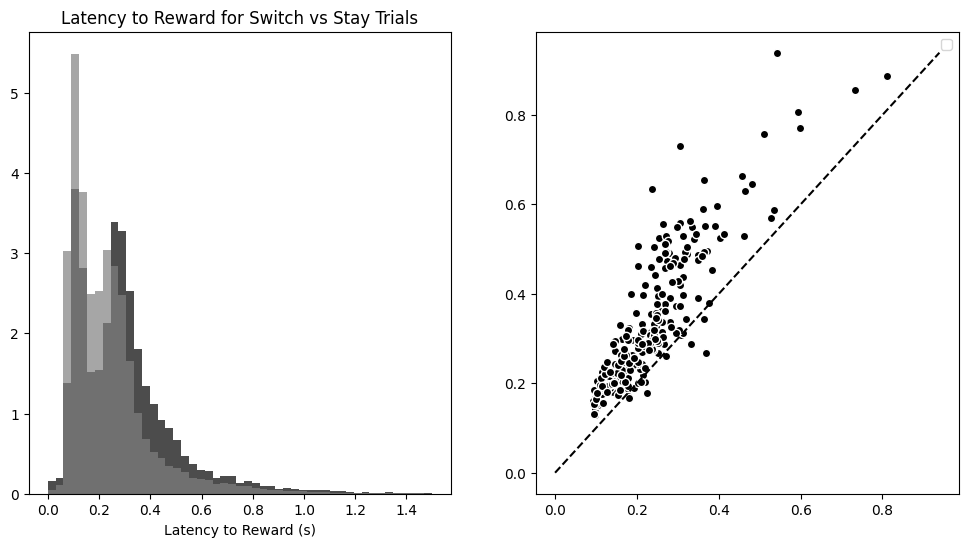

In [ ]:
# histogram
fig, axes = plt.subplots(1, 2, figsize=(12,6))
bin_num = 50
edges = np.linspace(0, 1.5, bin_num)
# edges = np.logspace(np.log10(0.01), np.log10(1.5), bin_num)
axes[0].hist(all_switch_lat, bins=edges, alpha=0.7, label='Switch Trials', density=True, color='k')
axes[0].hist(all_stay_lat, bins=edges, alpha=0.7, label='Stay Trials', density=True, color = 'gray')
axes[0].set_xlabel('Latency to Reward (s)')
axes[0].set_label('Density')
axes[0].set_title('Latency to Reward for Switch vs Stay Trials')
plt.legend()
# axes[0].set_xscale('log')

# compare mean latencies
axes[1].scatter(np.array(all_stay_mean), np.array(all_switch_mean), alpha=1, color='k', edgecolor = 'w')
# plot diagonal line
max_val = max(max(all_stay_mean), max(all_switch_mean))
axes[1].plot([0, max_val], [0, max_val], 'k--')
# log scale
# axes[1].set_xscale('log')
# axes[1]

save_panels(fig, target_folder, 'switch_stay_latency_comparison', ['FigureS12d'], exts=('pdf',))
# ---- panel CSVs (rule 7: histogram [d_top] + scatter [d_bottom], both in this cell) ----
save_panel_csv(columns_to_df(switch_latency_s=np.asarray(all_switch_lat), stay_latency_s=np.asarray(all_stay_lat)), target_folder, 'switch_stay_latency_comparison', ['FigureS12d'], plot_type='histogram')
save_panel_csv(columns_to_df(stay_mean_s=np.asarray(all_stay_mean), switch_mean_s=np.asarray(all_switch_mean)), target_folder, 'switch_stay_latency_comparison', ['FigureS12d'], plot_type='scatter')

##FigureS12d##

In [7]:
def analyze_animal_licks(animal_id, tb = -5, tf = 5, plot=False, video = False):
    dfs = [pd.read_csv(CAPSULE_ROOT + '/code/data_management/session_assets.csv'),
            pd.read_csv(CAPSULE_ROOT + '/code/data_management/hopkins_session_assets.csv')]
    df = pd.concat(dfs)
    session_list = df['session_id'].values.tolist()
    ani_list = [str(session).split('_')[1] for session in session_list if str(session).startswith('behavior')]
    session_list = [session for session in session_list if str(session).startswith('behavior')]
    ani_session_df = pd.DataFrame({'animal': ani_list, 'session_id': session_list})

    video_sessions = 0
    beh_sessions = 0

    aligned_licks = []
    in_out_mask = []
    lick_len = []
    rewarded_licks = []
    session_tbl_combined = []
    rl_ratio_out = []
    rl_ratio_in = []
    rl_ratio_outvsin = []
    rl_ratio_choice = []
    rl_ratio_in_reward_choices = []
    session_used = []
    sessions = ani_session_df[ani_session_df['animal'] == animal_id]['session_id'].values.tolist()
    if len(sessions) == 0:
        return
    for session in sessions:
        session_tbl = get_session_tbl(session)
        if session_tbl is None:
            continue
        # Concate licks
        if not video:
            licks = load_licks(session)
            beh_sessions += 1
        else:
            licks = load_licks_video(session, plot=False, inter_train_interval=1000)
            if licks is None:
                print(f'{session} has no video data, loading behavioral licks instead')
                licks = load_licks(session, plot=False, inter_train_interval=1000)
                beh_sessions += 1
            else:
                video_sessions += 1
        aligned_licks_sess = []
        in_out_mask_sess = []
        len_sess = []
        rewarded_licks_sess = []
        all_licks = licks['lick_trains_all']['train_starts']
        in_trial_session = licks['lick_trains_all']['in_trial']
        lick_len_session = licks['lick_trains_all']['train_ends'] - licks['lick_trains_all']['train_starts']
        lick_sides = licks['lick_trains_all']['side']
        for idx, row in session_tbl.iterrows():
            choice_times = row[ 'goCue_start_time']
            mask = (all_licks >= choice_times + tb) & (all_licks <= choice_times + tf)
            if idx < (len(session_tbl) - 1):
                mask &= (all_licks < session_tbl.iloc[idx+1]['goCue_start_time'] + tb)
            if idx > 0:
                mask &= (all_licks > session_tbl.iloc[idx-1]['goCue_start_time'] + tf)
            aligned_licks_trial = list(all_licks[mask] - choice_times)
            in_out_mask_trial = list(in_trial_session[mask])
            len_trial = list(lick_len_session[mask])
            aligned_licks_sess.extend(aligned_licks_trial)
            in_out_mask_sess.extend(in_out_mask_trial)
            len_sess.extend(list(lick_len_session[mask]))

            if len(aligned_licks_trial) == 0:
                continue
            rewarded_mask_trial = np.array([False]*len(aligned_licks_trial))
            if row['rewarded_historyR'] or row['rewarded_historyL']:
                rewarded_mask_trial[np.array(in_out_mask_trial)] = True
            rewarded_licks_sess.extend(list(rewarded_mask_trial))
                
        aligned_licks.append(aligned_licks_sess)
        in_out_mask.append(in_out_mask_sess)
        lick_len.append(len_sess)
        rewarded_licks.append(rewarded_licks_sess)
        # concat beh
        # for for each session, for each trial, compute: whether there's a lick train within [2.5 to 8] after go cue but before next go cue; how long has current trial been from last switch, how long until next switch
        choices_latent = session_tbl['animal_response'].values
        no_response_ind = np.where(choices_latent == 2)[0]
        no_response_ind = no_response_ind[no_response_ind > 0]
        choices_latent[no_response_ind] = choices_latent[no_response_ind - 1]
        switch_stay = choices_latent[1:] != choices_latent[:-1]
        switch_stay_pre = np.insert(switch_stay, 0, False)
        switch_stay_post = np.append(switch_stay, np.nan)
        session_tbl['switch_stay_pre'] = switch_stay_pre
        session_tbl['switch_stay_post'] = switch_stay_post
        # for each trial, compute how long since last switch
        last_switch = np.zeros(len(session_tbl))
        for i in range(1, len(session_tbl)):
            # after a switch
            if i >= np.where(switch_stay)[0][0]:
                if session_tbl.iloc[i-1]['switch_stay_post']:
                    last_switch[i] = 0
                else:
                    last_switch[i] = last_switch[i-1] + 1
            else:
                last_switch[i] = i
        session_tbl['trials_since_last_switch'] = last_switch
        # for each trial, compute how long until next switch
        next_switch = np.zeros(len(session_tbl))
        for i in range(len(session_tbl)-2, -1, -1):
            # before a switch
            if i <= np.where(switch_stay)[0][-1]:
                if session_tbl.iloc[i]['switch_stay_post']:
                    next_switch[i] = 0
                else:
                    next_switch[i] = next_switch[i+1] + 1
            else:
                next_switch[i] = np.nan
        session_tbl['trials_until_next_switch'] = next_switch
        
        # for each trial compute if there's a lick train within [2 to 8] after go cue but before next go cue
        lick_in_trial_post = np.zeros(len(session_tbl), dtype=bool)
        lick_in_trial_side = np.array([np.nan]*len(session_tbl))
        for idx, row in session_tbl.iterrows():
            align_time = row['goCue_start_time']
            mask = (all_licks >= align_time + 2) & (all_licks <= align_time + 8)
            if idx < (len(session_tbl) - 1):
                next_trial_start = session_tbl.iloc[idx+1]['goCue_start_time']
            else:
                next_trial_start = np.inf
            
            if np.sum(mask) > 0:
                lick_in_trial_post[idx] = True
            if np.all(all_licks[mask]) > next_trial_start:
                lick_in_trial_post[idx] = np.nan
            
            if lick_in_trial_post[idx]:
                lick_side_curr = lick_sides[mask]
                lick_in_trial_side[idx] = np.mean(lick_side_curr)
        session_tbl['lick_in_trial_post'] = lick_in_trial_post
        session_tbl['lick_in_trial_side_post'] = lick_in_trial_side

        # lick in following ITI
        lick_in_iti = np.zeros(len(session_tbl), dtype=bool)
        lick_in_iti_side = np.array([np.nan]*len(session_tbl))
        lick_in_iti_time = np.array([np.nan]*len(session_tbl))
        for idx, row in session_tbl.iterrows():
            align_time = row['goCue_start_time']
            if idx < (len(session_tbl) - 1):
                next_trial_start = session_tbl.iloc[idx+1]['goCue_start_time']
            else:
                next_trial_start = np.inf
            mask = (all_licks > align_time + 2) & (all_licks < next_trial_start)
            if np.sum(mask) > 0:
                lick_in_iti[idx] = True
            
            if lick_in_iti[idx]:
                lick_side_curr = lick_sides[mask]
                lick_mean = np.mean(lick_side_curr)
                lick_in_iti_side[idx] = (
                    1 if lick_mean > 0.5
                    else 0 if lick_mean < 0.5
                    else np.nan
                )
                lick_in_iti_time[idx] = all_licks[mask][0] - align_time
        
        session_tbl['lick_in_iti'] = lick_in_iti
        session_tbl['lick_in_iti_side'] = lick_in_iti_side
        session_tbl['lick_in_iti_time'] = lick_in_iti_time

        # licks before choice
        lick_in_trial_pre = np.zeros(len(session_tbl), dtype=bool)
        lick_in_trial_side_pre = np.array([np.nan]*len(session_tbl))
        for idx, row in session_tbl.iterrows():
            align_time = row['goCue_start_time']
            mask = (all_licks >= align_time - 5) & (all_licks <= align_time)
            if idx > 0:
                prev_trial_end = session_tbl.iloc[idx-1]['goCue_start_time']
            else:
                prev_trial_end = -np.inf
            
            if np.sum(mask) > 0:
                lick_in_trial_pre[idx] = True
            if np.all(all_licks[mask]) < prev_trial_end:
                lick_in_trial_pre[idx] = np.nan
            
            if lick_in_trial_pre[idx]:
                lick_side_curr = 2*(lick_sides[mask] - 0.5)
                lick_in_trial_side_pre[idx] = np.mean(lick_side_curr)
        session_tbl['lick_in_trial_pre'] = lick_in_trial_pre
        session_tbl['lick_in_trial_side_pre'] = lick_in_trial_side_pre

        session_tbl['outcome'] = session_tbl['rewarded_historyR'] | session_tbl['rewarded_historyL']
        session_tbl['outcome_pre'] = np.insert(session_tbl['outcome'].values[:-1], 0, False)
        session_tbl['choice'] = np.nan
        session_tbl.loc[session_tbl['animal_response'] == 1, 'choice'] = 1
        session_tbl.loc[session_tbl['animal_response'] == 0, 'choice'] = -1
        session_tbl['choice_pre'] = np.insert(session_tbl['choice'].values[:-1], 0, np.nan)
        session_tbl['choice_next'] = np.append(session_tbl['choice'].values[1:], np.nan)
        session_tbl['iti_length' ] = np.append(np.diff(session_tbl['goCue_start_time'].values), np.nan)

        session_tbl_combined.append(session_tbl)

        # right left ratio in out of trial licks
        rl_ratio_out_curr = (np.sum(licks['lick_trains_R']['in_trial'] == False) - np.sum(licks['lick_trains_L']['in_trial'] == False))/(np.sum(licks['lick_trains_R']['in_trial'] == False) + np.sum(licks['lick_trains_L']['in_trial'] == False))
        rl_ratio_in_choice_curr = (np.sum(session_tbl['animal_response'].values == 1) - np.sum(session_tbl['animal_response'].values == 0))/(np.sum(session_tbl['animal_response'].values == 1) + np.sum(session_tbl['animal_response'].values == 0))
        rl_ratio_in_curr = (np.sum(licks['lick_trains_R']['in_trial'] == True) - np.sum(licks['lick_trains_L']['in_trial'] == True))/(np.sum(licks['lick_trains_R']['in_trial'] == True) + np.sum(licks['lick_trains_L']['in_trial'] == True))
        reward_mask = (session_tbl['rewarded_historyR'] | session_tbl['rewarded_historyL']).values
        resp = session_tbl.loc[reward_mask, 'animal_response'].values
        rl_ratio_in_reward_choices_curr = (np.sum(resp == 1) - np.sum(resp == 0))/(np.sum(resp == 1) + np.sum(resp == 0))
        rl_ratio_out.append(rl_ratio_out_curr)
        rl_ratio_in.append(rl_ratio_in_curr)
        rl_ratio_outvsin.append(rl_ratio_out_curr - rl_ratio_in_curr)
        rl_ratio_choice.append(rl_ratio_in_choice_curr)
        rl_ratio_in_reward_choices.append(rl_ratio_in_reward_choices_curr)
        session_used.append(session)

    if len(aligned_licks) == 0:
        return
    
    # Compute session-wise statistics
    len_session_mean = [np.mean(np.array(lick_len_sess)) if len(lick_len_sess) > 0 else np.nan for lick_len_sess in lick_len]
    len_in_rwd_session_mean = [np.mean(np.array(lick_len_sess)[np.array(in_out_mask_sess) & np.array(rewarded_licks_session)]) 
                                if np.sum(np.array(in_out_mask_sess) & np.array(rewarded_licks_session)) > 0 else 0 
                                for lick_len_sess, in_out_mask_sess, rewarded_licks_session in zip(lick_len, in_out_mask, rewarded_licks)]
    len_in_no_rwd_session_mean = [np.mean(np.array(lick_len_sess)[np.array(in_out_mask_sess) & ~np.array(rewarded_licks_session)])
                                if np.sum(np.array(in_out_mask_sess) & ~np.array(rewarded_licks_session)) > 0 else 0
                                for lick_len_sess, in_out_mask_sess, rewarded_licks_session in zip(lick_len, in_out_mask, rewarded_licks)]
    len_out_session_mean = [np.mean(np.array(lick_len_sess)[~np.array(in_out_mask_sess)]) if np.sum(~np.array(in_out_mask_sess)) > 0 else 0 for lick_len_sess, in_out_mask_sess in zip(lick_len, in_out_mask)]
    
    
    count_session = [len(lick_len_sess) for lick_len_sess in lick_len]
    count_in_rwd_session = [np.sum(np.array(in_out_mask_sess) & np.array(rewarded_licks_session)) 
                            for in_out_mask_sess, rewarded_licks_session in zip(in_out_mask, rewarded_licks)]
    count_in_nrwd_session = [np.sum(np.array(in_out_mask_sess) & ~np.array(rewarded_licks_session))
                            for in_out_mask_sess, rewarded_licks_session in zip(in_out_mask, rewarded_licks)]
    count_out_session = [np.sum(~np.array(in_out_mask_sess)) for in_out_mask_sess in in_out_mask]

    quantiles = [0.25, 0.5, 0.75]
    quantiles_session = [np.quantile(np.array(lick_len_sess), quantiles) if len(lick_len_sess) > 0 else [np.nan]*len(quantiles) for lick_len_sess in lick_len]
    quantiles_in_rwd_session = [np.quantile(np.array(lick_len_sess)[np.array(in_out_mask_sess) & np.array(rewarded_licks_session)], quantiles) 
                                if np.sum(np.array(in_out_mask_sess) & np.array(rewarded_licks_session)) > 0 else [np.nan]*len(quantiles) 
                                for lick_len_sess, in_out_mask_sess, rewarded_licks_session in zip(lick_len, in_out_mask, rewarded_licks)]
    qualtiles_in_nrwd_session = [np.quantile(np.array(lick_len_sess)[np.array(in_out_mask_sess) & ~np.array(rewarded_licks_session)], quantiles)
                                if np.sum(np.array(in_out_mask_sess) & ~np.array(rewarded_licks_session)) > 0 else [np.nan]*len(quantiles)
                                for lick_len_sess, in_out_mask_sess, rewarded_licks_session in zip(lick_len, in_out_mask, rewarded_licks)]
    quantiles_out_session = [np.quantile(np.array(lick_len_sess)[~np.array(in_out_mask_sess)], quantiles) if np.sum(~np.array(in_out_mask_sess)) > 0 else [np.nan]*len(quantiles) for lick_len_sess, in_out_mask_sess in zip(lick_len, in_out_mask)]

    ratio_session = [np.mean(in_out_mask_sess) if len(lick_len_sess) > 0 else np.nan for lick_len_sess, in_out_mask_sess in zip(lick_len, in_out_mask)]
    ratio_out_session = []
    ratio_int_session = []
    for lick_len_sess, in_out_mask_sess in zip(lick_len, in_out_mask):
        if np.sum(~np.array(in_out_mask_sess)) > 0 and np.sum(np.array(in_out_mask_sess)) > 0:
            ratio_out_session.append(np.sum(~np.array(in_out_mask_sess))/len(lick_len_sess))
            ratio_int_session.append(np.sum(np.array(in_out_mask_sess))/len(lick_len_sess))
        else:
            ratio_out_session.append(np.nan)
            ratio_int_session.append(np.nan)

    # Combine all session-wise list into a big list
    lick_len = [item for sublist in lick_len for item in sublist]
    aligned_licks = [item for sublist in aligned_licks for item in sublist]
    in_out_mask = [item for sublist in in_out_mask for item in sublist]
    rewarded_licks = [item for sublist in rewarded_licks for item in sublist]

    len_mean_combined = np.mean(np.array(lick_len))
    len_mean_out_combined = np.mean(np.array(lick_len)[~np.array(in_out_mask)])
    len_mean_in_rwd_combined = np.mean(np.array(lick_len)[np.array(in_out_mask) & np.array(rewarded_licks)])
    len_mean_in_nrwd_combined = np.mean(np.array(lick_len)[np.array(in_out_mask) & ~np.array(rewarded_licks)])
    quantiles_combined = np.quantile(np.array(lick_len), quantiles)
    quantiles_out_combined = np.quantile(np.array(lick_len)[~np.array(in_out_mask)], quantiles)
    quantiles_in_rwd_combined = np.quantile(np.array(lick_len)[np.array(in_out_mask) & np.array(rewarded_licks)], quantiles)
    quantiles_in_nrwd_combined = np.quantile(np.array(lick_len)[np.array(in_out_mask) & ~np.array(rewarded_licks)], quantiles)


    # ratio of out of trial licks between right and left
     
    results = {'session_ids': session_used,
            'animal_id': animal_id,
            'all_licks': {'len_mean': len_session_mean,
                        'count': count_session,
                        'quantiles': quantiles_session},
            'in_trial_rwd_licks': {'len_mean': len_in_rwd_session_mean,
                'count': count_in_rwd_session,
                'quantiles': quantiles_in_rwd_session},
            'in_trial_no_rwd_licks': {'len_mean': len_in_no_rwd_session_mean,
                'count': count_in_nrwd_session,
                'quantiles': qualtiles_in_nrwd_session},
            'out_of_trial_licks': {'len_mean': len_out_session_mean,
                'count': count_out_session,
                'quantiles': quantiles_out_session},
            'in_out_ratio': ratio_session,
            'rl_ratio_out': rl_ratio_out,
            'rl_ratio_in': rl_ratio_in,
            'rl_ratio_outvsin': rl_ratio_outvsin,
            'rl_ratio_choice': rl_ratio_choice,
            'rl_ratio_in_reward_choices': rl_ratio_in_reward_choices,
            'combined': {'all': {'len_mean': len_mean_combined,
                                'quantiles': quantiles_combined},
                        'in_trial_rwd': {'len_mean': len_mean_in_rwd_combined,
                                        'quantiles': quantiles_in_rwd_combined},
                        'in_trial_no_rwd': {'len_mean': len_mean_in_nrwd_combined,
                                            'quantiles': quantiles_in_nrwd_combined},
                        'out_of_trial': {'len_mean': len_mean_out_combined,
                                        'quantiles': quantiles_out_combined}
                        }
            }
        
    # save combined results to pickle
    save_file = str(capsule_directories()['derived_dir']) + f'/{animal_id}/ani_combinded/lick_train_stats_video_{video}.pkl'
    with open(save_file, 'wb') as f:
        pickle.dump(results, f)

    # model
    session_tbl_combined = pd.concat(session_tbl_combined)
    # convert all boolean columns to numeric
    bool_cols = session_tbl_combined.select_dtypes(include=['bool']).columns
    session_tbl_combined[bool_cols] = session_tbl_combined[bool_cols].astype(int)

    # zscore if not only between -1 and 1
    for col in ['trials_since_last_switch', 'trials_until_next_switch']:
        session_tbl_combined[col] = session_tbl_combined[col].values/10
    
    model_post = 'lick_in_trial_post ~ trials_since_last_switch + trials_until_next_switch + outcome'
    model_pre = 'lick_in_trial_pre ~ trials_since_last_switch + trials_until_next_switch + outcome_pre'
    model_iti = 'lick_in_iti ~ trials_since_last_switch + switch_stay_post + outcome + iti_length'
    model_side_post = 'lick_in_trial_side_post ~ choice'
    model_side_pre = 'lick_in_trial_side_pre ~ choice_pre'
    model_side_iti = 'lick_in_iti_side ~ choice*lick_in_iti_time + choice + choice_next'
    
    try:
        lm_post = sm.Logit.from_formula(model_post, data=session_tbl_combined).fit()
    except:
        lm_post = None
        print(f'{session} Post model failed to fit')
    try:
        lm_pre = sm.Logit.from_formula(model_pre, data=session_tbl_combined).fit()
    except:
        lm_pre = None
        print(f'{session} Pre model failed to fit')
    try:
        lm_iti = sm.Logit.from_formula(model_iti, data=session_tbl_combined).fit()
    except:
        lm_iti = None
        print(f'{session} ITI model failed to fit')
    try:
        lm_side_post = sm.OLS.from_formula(model_side_post, data=session_tbl_combined).fit()
    except:
        lm_side_post = None
        print(f'{session} Side post model side failed to fit')
    try:
        lm_side_pre = sm.OLS.from_formula(model_side_pre, data=session_tbl_combined).fit()
    except:
        lm_side_pre = None
        print(f'{session} Side pre model side failed to fit')
    try:
        lm_side_iti = sm.Logit.from_formula(model_side_iti, data=session_tbl_combined).fit()
    except:
        lm_side_iti = None
        print(f'{session} Side iti model side failed to fit')

    # save model results to pickle
    model_results = {'lm_post': lm_post,
                    'lm_pre': lm_pre,
                    'lm_side_post': lm_side_post,
                    'lm_side_pre': lm_side_pre,
                    'lm_iti': lm_iti,
                    'lm_side_iti': lm_side_iti}
    save_file = str(capsule_directories()['derived_dir']) + f'/{animal_id}/ani_combinded/lick_in_trial_model_video_{video}.pkl'
    with open(save_file, 'wb') as f:
        pickle.dump(model_results, f)

    if plot:
        # train_lens
        fig = plt.figure(figsize=(8,4))
        gs = gridspec.GridSpec(1,2)
        # lick time
        ax1 = fig.add_subplot(gs[0, 0])
        edges = np.linspace(tb, tf, 50)
        ax1.hist(np.array(aligned_licks)[np.array(in_out_mask)], bins=edges, density=True, color='k', label='in-trial');
        ax1.hist(np.array(aligned_licks)[~np.array(in_out_mask)], bins=edges, density=True, alpha=0.5, color='gray', label='out-of-trial');
        ax1.set_title(f'Lick times aligned to choice, out = {np.sum(~np.array(in_out_mask))}, in = {np.sum(np.array(in_out_mask))}')
        ax1.set_xlabel('Time from choice (s)')
        ax1.set_ylabel('Density')
        ax1.legend()

        ax = fig.add_subplot(gs[0, 1])
        edges = np.linspace(np.min(lick_len), np.max(lick_len), 30)
        ax.hist(np.array(lick_len)[np.array(in_out_mask) & np.array(rewarded_licks)], bins=edges, color='r', label='in-trial_R', density=True);
        ax.hist(np.array(lick_len)[np.array(in_out_mask) & ~np.array(rewarded_licks)], bins=edges, color='k', label='in-trial_N', density=True);
        ax.hist(np.array(lick_len)[~np.array(in_out_mask)], bins=edges, alpha=0.5, color='gray', label='out-of-trial', density=True);
        ax.set_title('Lick train lengths')
        ax.set_xlabel('Lick train length (s)')
        ax.set_ylabel('Density')
        ax.legend()

        plt.suptitle(f'Animal {animal_id} lick statistics across {len(sessions)} sessions')
        ani_dir = str(capsule_directories()['derived_dir']) + f'/{animal_id}/ani_combinded'
        if not os.path.exists(ani_dir):
            os.makedirs(ani_dir)
        plt.tight_layout()
        fig.savefig(fname=os.path.join(ani_dir, f'lick_trains_video_{video}.pdf'), dpi=300)

        # plot model results as coefficient bar plots
        fig = plt.figure(figsize=(8,8))
        gs = gridspec.GridSpec(3, 2, hspace=0.4)
        # pre model
        if lm_pre is not None:
            ax1 = fig.add_subplot(gs[0, 0])

            z_pre   = lm_pre.tvalues[1:]
            sig_pre = lm_pre.pvalues[1:] < 0.05

            # colors per bar
            colors = ['r' if sig else 'gray' for sig in sig_pre.values]

            ax1.bar(
                z_pre.index,
                z_pre.values,
                color=colors,
                alpha=0.7,
            )

            ax1.set_title('Spont licks (pre-choice)')
            ax1.set_ylabel('z value')
            ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
        if lm_side_pre is not None:
            ax2 = fig.add_subplot(gs[0, 1])
            z_side_pre   = lm_side_pre.tvalues[1:]
            sig_side_pre = lm_side_pre.pvalues[1:] < 0.05
            # colors per bar
            colors = ['r' if sig else 'gray' for sig in sig_side_pre.values]
            ax2.bar(
                z_side_pre.index,
                z_side_pre.values,
                color=colors,
                alpha=0.7,
            )
            ax2.set_title('Spont licks side (pre-choice)')
            ax2.set_ylabel('z value')
            ax2.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
        if lm_post is not None:
            # post model
            ax3 = fig.add_subplot(gs[1, 0])
            z_post   = lm_post.tvalues[1:]
            sig_post = lm_post.pvalues[1:] < 0.05
            # colors per bar
            colors = ['r' if sig else 'gray' for sig in sig_post.values]
            ax3.bar(
                z_post.index,
                z_post.values,
                color=colors,
                alpha=0.7,
            )
            ax3.set_title('Spont licks (post-choice)')
            ax3.set_ylabel('z value')
            ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
        if lm_side_post is not None:
            ax4 = fig.add_subplot(gs[1, 1])
            z_side_post   = lm_side_post.tvalues[1:]
            sig_side_post = lm_side_post.pvalues[1:] < 0.05
            # colors per bar
            colors = ['r' if sig else 'gray' for sig in sig_side_post.values]
            ax4.bar(
                z_side_post.index,
                z_side_post.values,
                color=colors,
                alpha=0.7,
            )
            ax4.set_title('Spont licks side (post-choice)')
            ax4.set_ylabel('z value')
            ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
        if lm_iti is not None:
            ax5 = fig.add_subplot(gs[2, 0])
            z_iti   = lm_iti.tvalues[1:]
            sig_iti = lm_iti.pvalues[1:] < 0.05
            # colors per bar
            colors = ['r' if sig else 'gray' for sig in sig_iti.values]
            ax5.bar(
                z_iti.index,
                z_iti.values,
                color=colors,
                alpha=0.7,
            )
            ax5.set_title('Spont licks (ITI)')
            ax5.set_ylabel('z value')
            ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right')
        if lm_side_iti is not None:
            ax6 = fig.add_subplot(gs[2, 1])
            z_side_iti   = lm_side_iti.tvalues[1:]
            sig_side_iti = lm_side_iti.pvalues[1:] < 0.05
            # colors per bar
            colors = ['r' if sig else 'gray' for sig in sig_side_iti.values]
            ax6.bar(
                z_side_iti.index,
                z_side_iti.values,
                color=colors,
                alpha=0.7,
            )
            ax6.set_title('Spont licks side (ITI)')
            ax6.set_ylabel('z value')
            ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right')
            

        plt.suptitle(f'Animal {animal_id} lick across {beh_sessions} behavior and {video_sessions} video sessions')
        plt.tight_layout()
        fig.savefig(fname=os.path.join(ani_dir, f'lick_in_trial_model_coefficients_video_{video}.pdf'), dpi=300)


In [9]:
from joblib import Parallel, delayed

animal_ids = ani_session_df['animal'].unique().tolist()

results = Parallel(n_jobs=-1)(
    delayed(analyze_animal_licks)(animal_id, plot=False, video=True)
    for animal_id in animal_ids
)


Lick video file not found for session behavior_716325_2024-05-29_10-33-32. Please run the lick video processing pipeline first.
behavior_716325_2024-05-29_10-33-32 has no video data, loading behavioral licks instead
Lick video file not found for session behavior_739970_2024-10-15_10-04-12. Please run the lick video processing pipeline first.
behavior_739970_2024-10-15_10-04-12 has no video data, loading behavioral licks instead
Lick video file not found for session behavior_717263_2024-07-23_11-46-42. Please run the lick video processing pipeline first.
behavior_717263_2024-07-23_11-46-42 has no video data, loading behavioral licks instead
Lick video file not found for session behavior_717121_2024-06-11_10-23-31. Please run the lick video processing pipeline first.
behavior_717121_2024-06-11_10-23-31 has no video data, loading behavioral licks instead
Lick video file not found for session behavior_717259_2024-06-25_10-09-25. Please run the lick video processing pipeline first.
behavior

/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3

Optimization terminated successfully.
         Current function value: 0.580249
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.450771
         Iterations 6
         Current function value: 0.017344
         Iterations: 35
         Current function value: 0.010921
         Iterations: 35
behavior_722832_2024-09-13_11-55-58 Pre model failed to fit
Optimization terminated successfully.
         Current function value: 0.427405
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.226725
         Iterations 7
         Current function value: 0.274971
         Iterations: 35
         Current function value: inf
         Iterations: 35
behavior_739977_2024-10-24_12-58-26 Side iti model side failed to fit


/opt/conda/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/statsmodels/discrete/discrete_model

Lick video file not found for session behavior_717121_2024-06-13_12-21-20. Please run the lick video processing pipeline first.
behavior_717121_2024-06-13_12-21-20 has no video data, loading behavioral licks instead


...

/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Lick video file not found for session behavior_ZS062_2021-05-11_20-10-59. Please run the lick video processing pipeline first.
behavior_ZS062_2021-05-11_20-10-59 has no video data, loading behavioral licks instead


/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimization terminated successfully.
         Current function value: 0.584665
         Iterations 5
         Current function value: inf
         Iterations: 35
behavior_ZS062_2021-05-11_20-10-59 Pre model failed to fit
Optimization terminated successfully.
         Current function value: 0.443354
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.692272
         Iterations 4


/opt/conda/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/conda/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


In [10]:
# load data from all animals and plot summary statistics
animal_ids = ani_session_df['animal'].unique().tolist()
all_results = []
all_results_model = []
for animal_id in animal_ids:
    save_file = str(capsule_directories()['derived_dir']) + f'/{animal_id}/ani_combinded/lick_train_stats_video_{video}.pkl' 
    if os.path.exists(save_file):
        with open(save_file, 'rb') as f:
            results = pickle.load(f)
        results['animal_id'] = animal_id
        all_results.append(results)
    else:
        print(f'No lick stats for animal {animal_id}')
    save_file = str(capsule_directories()['derived_dir']) + f'/{animal_id}/ani_combinded/lick_in_trial_model_video_{video}.pkl'
    if os.path.exists(save_file):
        with open(save_file, 'rb') as f:
            model_results = pickle.load(f)
        model_results['animal_id'] = animal_id
        all_results_model.append(model_results)
    else:
        print(f'No lick model for animal {animal_id}')

No lick stats for animal 744779
No lick model for animal 744779


In [12]:
# plot ratios.
variables_collect = ['in_out_ratio', 'rl_ratio_out', 'rl_ratio_in', 'rl_ratio_outvsin', 'session_ids', 'rl_ratio_choice', 'rl_ratio_in_reward_choices']
lick_stats_df = pd.DataFrame()
for result in all_results:
    lick_stats_dict = {var: result[var] for var in variables_collect}
    lick_stats_df_curr = pd.DataFrame(lick_stats_dict)
    lick_stats_df = pd.concat([lick_stats_df, lick_stats_df_curr], ignore_index=True)
lick_stats_df['ratio_diff_abs'] = np.abs(lick_stats_df['rl_ratio_out'] - lick_stats_df['rl_ratio_in'])
lick_stats_df['ratio_diff_rwd_abs'] = np.abs(lick_stats_df['rl_ratio_out'] - lick_stats_df['rl_ratio_in_reward_choices'])
variables_collect.append('ratio_diff_abs')
variables_collect.append('ratio_diff_rwd_abs')

In [24]:
lick_stats_df['ratio_diff_rwd'] = np.abs((lick_stats_df['rl_ratio_out'] - lick_stats_df['rl_ratio_in_reward_choices']))

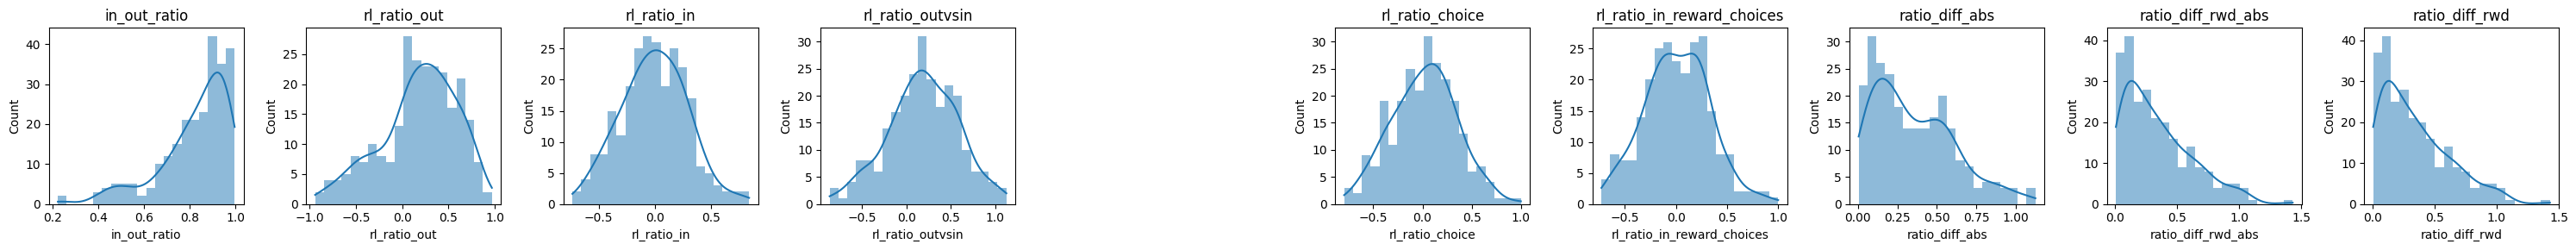

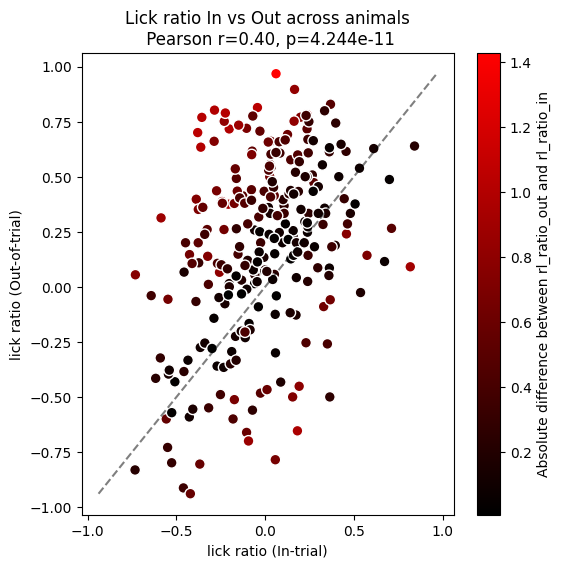

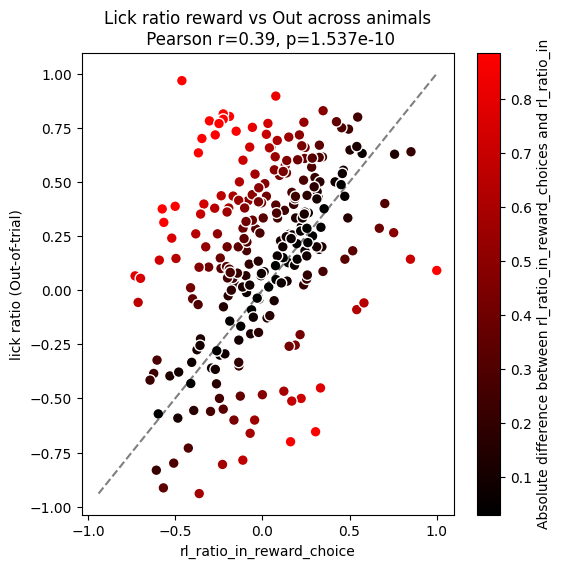

In [ ]:

# plot histogram distribution of all of them
fig = plt.figure(figsize=(3*len(lick_stats_df.columns), 3))
gs = gridspec.GridSpec(1, len(lick_stats_df.columns))
for i, var in enumerate(lick_stats_df.columns):
    # if numeric
    if lick_stats_df[var].dtype == 'O':
        continue
    ax = fig.add_subplot(gs[0, i])
    sns.histplot(lick_stats_df[var], ax=ax, kde=True, bins=20, edgecolor='None')
    ax.set_title(var)
plt.tight_layout()
fig.savefig(fname=os.path.join(target_folder, f'lick_stats_histograms_video_{video}.pdf'), dpi=3000)


black_red = LinearSegmentedColormap.from_list(
    "black_red",
    ["black", "red"]
)

# rl ratio out vs in across animals
fig = plt.figure(figsize=(6,6))
g = plt.scatter(lick_stats_df['rl_ratio_in'], lick_stats_df['rl_ratio_out'], alpha=1, s = 60, c=lick_stats_df['ratio_diff_rwd'], cmap=black_red, edgecolor= 'w')
# add diagnonal line
min_v = min(lick_stats_df['rl_ratio_in'].min(), lick_stats_df['rl_ratio_out'].min())
max_v = max(lick_stats_df['rl_ratio_in'].max(), lick_stats_df['rl_ratio_out'].max())
plt.plot([min_v, max_v], [min_v, max_v], 'k--', alpha=0.5)
# colorbar
plt.colorbar(g, label='Absolute difference between rl_ratio_out and rl_ratio_in')
# correlation and p values
corr, p_value = stats.pearsonr(lick_stats_df['rl_ratio_in'], lick_stats_df['rl_ratio_out'])
plt.xlabel('lick ratio (In-trial)')
plt.ylabel('lick ratio (Out-of-trial)')
plt.title(f'Lick ratio In vs Out across animals\n Pearson r={corr:.2f}, p={p_value:.3e}')
fig.savefig(fname=os.path.join(target_folder, f'lick_ratio_in_out_summary_video_{video}.pdf'), dpi=300)

fig = plt.figure(figsize=(6,6))
g = plt.scatter(lick_stats_df['rl_ratio_in_reward_choices'], lick_stats_df['rl_ratio_out'], alpha=1, s = 60, 
                c=lick_stats_df['ratio_diff_rwd'], cmap=black_red, edgecolor= 'w', vmin=lick_stats_df['ratio_diff_rwd'].quantile(0.05), vmax=lick_stats_df['ratio_diff_rwd'].quantile(0.95))
# correlation and p values
min_v = min(lick_stats_df['rl_ratio_in_reward_choices'].min(), lick_stats_df['rl_ratio_out'].min())
max_v = max(lick_stats_df['rl_ratio_in_reward_choices'].max(), lick_stats_df['rl_ratio_out'].max())
plt.plot([min_v, max_v], [min_v, max_v], 'k--', alpha=0.5)
plt.colorbar(g, label='Absolute difference between rl_ratio_in_reward_choices and rl_ratio_in')
corr, p_value = stats.pearsonr(lick_stats_df['rl_ratio_in_reward_choices'], lick_stats_df['rl_ratio_out'])
plt.xlabel('rl_ratio_in_reward_choice')
plt.ylabel('lick ratio (Out-of-trial)')
plt.title(f'Lick ratio reward vs Out across animals\n Pearson r={corr:.2f}, p={p_value:.3e}')

save_panels(fig, target_folder, f'lick_ratio_in_out_reward_summary_video_{video}', ['FigureS12h'], exts=('pdf',), dpi=300)
save_panel_csv(columns_to_df(rl_ratio_in_reward_choices=lick_stats_df['rl_ratio_in_reward_choices'].values, rl_ratio_out=lick_stats_df['rl_ratio_out'].values, ratio_diff_rwd=lick_stats_df['ratio_diff_rwd'].values), target_folder, f'lick_ratio_in_out_reward_summary_video_{video}', ['FigureS12h'])
##FigureS12h##


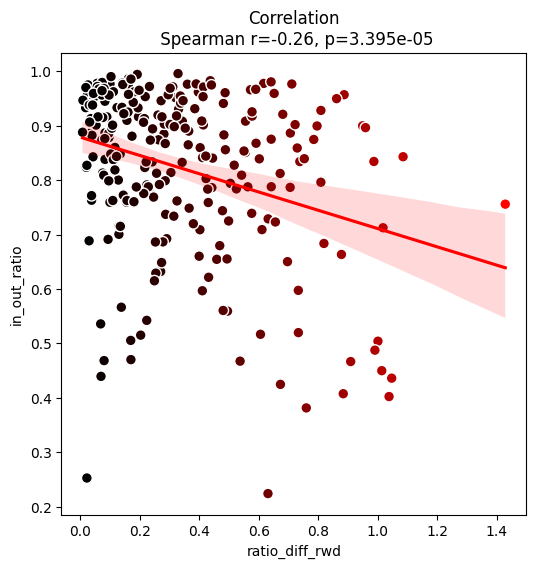

In [ ]:
fig = plt.figure(figsize=(6,6))
x = 'ratio_diff_rwd'
y = 'in_out_ratio'
color_code = 'ratio_diff_rwd'
plt.scatter(lick_stats_df[x], lick_stats_df[y], alpha=1, s = 60, c = lick_stats_df[color_code], cmap=black_red, edgecolor= 'w')
# add regression line and confidence interval
sns.regplot(x=lick_stats_df[x], y=lick_stats_df[y], scatter=False, ax=plt.gca(), line_kws={'color': 'red'})
# correlation and p values spearman
corr, p_value = stats.spearmanr(lick_stats_df[x], lick_stats_df[y])
plt.xlabel(x)
plt.ylabel(y)
plt.title(f'Correlation\n Spearman r={corr:.2f}, p={p_value:.3e}')
save_panels(fig, target_folder, f'lick_ratio_diff_in_reward_choice_vs_in_out_ratio_video_{video}', ['FigureS12i'], exts=('pdf',), dpi=300)
save_panel_csv(columns_to_df(ratio_diff_rwd=lick_stats_df['ratio_diff_rwd'].values, in_out_ratio=lick_stats_df['in_out_ratio'].values), target_folder, f'lick_ratio_diff_in_reward_choice_vs_in_out_ratio_video_{video}', ['FigureS12i'])
##FigureS12i##

In [27]:
# load all model results into a list
fit_values = {'post': [], 'pre': [], 'iti': [], 'side_post': [], 'side_pre': [], 'side_iti': []}
for result in all_results_model:
    animal_id = result['animal_id']
    for key in fit_values.keys():
        lm_key = 'lm_' + key
        lm = result[lm_key]
        if lm is not None:
            if key.startswith('side'):
                z_vals = lm.tvalues
                p_vals = lm.pvalues
            else:
                z_vals = lm.tvalues[1:]
                p_vals = lm.pvalues[1:]
            curr_df = pd.DataFrame({'animal_id': animal_id, 'regressor': z_vals.index, 'z_value': z_vals.values, 'model': key, 'p_value': p_vals.values})
            fit_values[key].append(curr_df)
# combine each field into one dataframe
for key in fit_values.keys():
    if len(fit_values[key]) > 0:
        fit_values[key] = pd.concat(fit_values[key])
    else:
        print(f'No model fits for {key}')




/tmp/ipykernel_2227764/3651247383.py:22: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


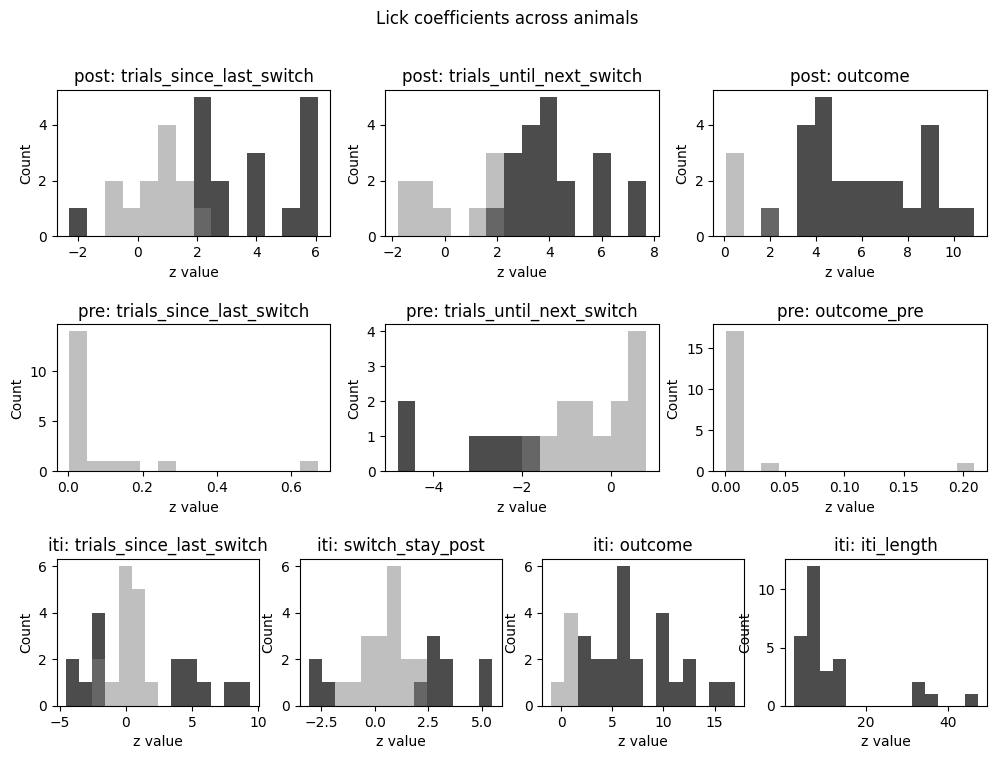

In [ ]:
# plot model z values across animals as histograms
# each row is a model (post, pre, iti), each column is a regressor
fig = plt.figure(figsize=(12,8))
model_keys = ['post', 'pre', 'iti']
for row_ind, model_key in enumerate(model_keys):
    model_df = fit_values[model_key]
    regressors = model_df['regressor'].unique().tolist()
    for col_ind, regressor in enumerate(regressors):
        ax = fig.add_subplot(len(model_keys), len(regressors), row_ind*len(regressors) + col_ind + 1)
        reg_df = model_df[model_df['regressor'] == regressor]
        # significant in red, non-significant in gray
        sig_mask = reg_df['p_value'] < 0.05
        bin_edges = np.linspace(np.min(reg_df['z_value']), np.max(reg_df['z_value']), 15)
        ax.hist(reg_df[sig_mask]['z_value'], bins=bin_edges, color='k', alpha=0.7, label='p < 0.05')
        ax.hist(reg_df[~sig_mask]['z_value'], bins=bin_edges, color='gray', alpha=0.5, label='p >= 0.05')

        ax.set_title(f'{model_key}: {regressor}')
        ax.set_xlabel('z value')
        ax.set_ylabel('Count')
plt.suptitle('Lick coefficients across animals')
fig.subplots_adjust(hspace=0.6)
plt.tight_layout()
save_panels(fig, target_folder, f'lick_model_coefficients_summary_video_{video}', ['FigureS12j'], exts=('pdf',), dpi=300)
# ---- panel CSV (rule 8 histogram: z-values per model/regressor, split sig/nonsig) ----
_zc = {}
for _mk in ['post', 'pre', 'iti']:
    _mdf = fit_values[_mk]
    for _reg in _mdf['regressor'].unique().tolist():
        _rdf = _mdf[_mdf['regressor'] == _reg]; _sig = _rdf['p_value'] < 0.05
        _zc[f'{_mk}_{_reg}_sig'] = _rdf[_sig]['z_value'].values
        _zc[f'{_mk}_{_reg}_nonsig'] = _rdf[~_sig]['z_value'].values
save_panel_csv(columns_to_df(**_zc), target_folder, f'lick_model_coefficients_summary_video_{video}', ['FigureS12j'])
##FigureS12j##

In [34]:
lick_stats_df.columns

Index(['rl_ratio_out', 'rl_ratio_in', 'rl_ratio_outvsin', 'session_ids',
       'in_out_ratio_mean', 'animal_id'],
      dtype='object')